In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv("patient-vitals.csv")
df.head()

,Patient_ID,Age,Gender,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP
0,P001,25,M,72,98,36.7,120,80
1,P002,34,F,85,97,37.1,128,84
2,P003,52,M,91,95,37.4,140,90
3,P004,41,F,76,99,36.8,118,78
4,P005,67,M,102,93,38.1,150,95


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Patient_ID    10 non-null     object 
 1   Age           10 non-null     int64  
 2   Gender        10 non-null     object 
 3   Heart_Rate    10 non-null     int64  
 4   SpO2          10 non-null     int64  
 5   Temperature   10 non-null     float64
 6   Systolic_BP   10 non-null     int64  
 7   Diastolic_BP  10 non-null     int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 772.0+ bytes


In [6]:
df.describe()

,Age,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,46.000000,84.500000,96.300000,37.190000,131.800000,85.600000
std,15.881506,13.550318,2.626785,0.653962,14.642404,7.720104
min,25.000000,68.000000,91.000000,36.500000,115.000000,76.000000
25%,35.000000,74.500000,95.250000,36.725000,120.500000,80.000000
50%,43.000000,82.000000,97.000000,37.050000,129.000000,84.500000
75%,55.000000,90.250000,98.000000,37.350000,138.750000,89.500000
max,73.000000,110.000000,99.000000,38.500000,160.000000,100.000000


In [7]:
df.isnull().sum()

Patient_ID      0
Age             0
Gender          0
Heart_Rate      0
SpO2            0
Temperature     0
Systolic_BP     0
Diastolic_BP    0
dtype: int64

In [8]:
def classify_patient(row):
    if row["SpO2"] < 95 or row["Heart_Rate"] > 100 or row["Temperature"] >= 38:
        return "Needs Attention"
    else:
        return "Normal"

df["Status"] = df.apply(classify_patient, axis=1)

df[["Patient_ID", "Heart_Rate", "SpO2", "Temperature", "Status"]]

,Patient_ID,Heart_Rate,SpO2,Temperature,Status
0,P001,72,98,36.7,Normal
1,P002,85,97,37.1,Normal
2,P003,91,95,37.4,Normal
3,P004,76,99,36.8,Normal
4,P005,102,93,38.1,Needs Attention
5,P006,68,98,36.6,Normal
6,P007,110,91,38.5,Needs Attention
7,P008,88,96,37.2,Normal
8,P009,79,97,37.0,Normal
9,P010,74,99,36.5,Normal


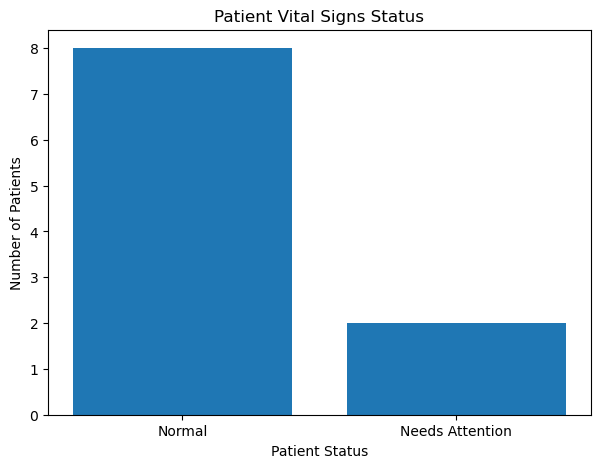

In [9]:
status_counts = df["Status"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(status_counts.index, status_counts.values)

plt.xlabel("Patient Status")
plt.ylabel("Number of Patients")
plt.title("Patient Vital Signs Status")

plt.show()

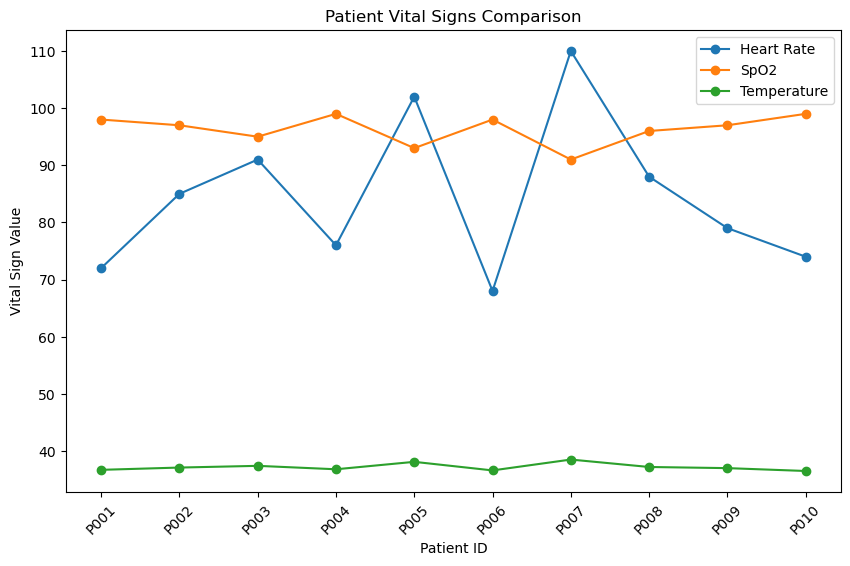

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(df["Patient_ID"], df["Heart_Rate"], marker="o", label="Heart Rate")
plt.plot(df["Patient_ID"], df["SpO2"], marker="o", label="SpO2")
plt.plot(df["Patient_ID"], df["Temperature"], marker="o", label="Temperature")

plt.xlabel("Patient ID")
plt.ylabel("Vital Sign Value")
plt.title("Patient Vital Signs Comparison")
plt.legend()
plt.xticks(rotation=45)

plt.show()

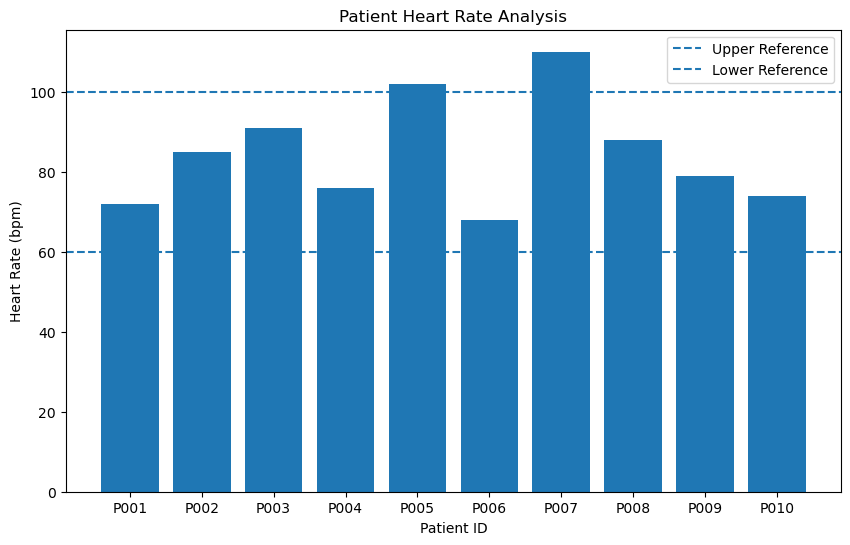

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(df["Patient_ID"], df["Heart_Rate"])

plt.axhline(100, linestyle="--", label="Upper Reference")
plt.axhline(60, linestyle="--", label="Lower Reference")

plt.xlabel("Patient ID")
plt.ylabel("Heart Rate (bpm)")
plt.title("Patient Heart Rate Analysis")
plt.legend()

plt.show()

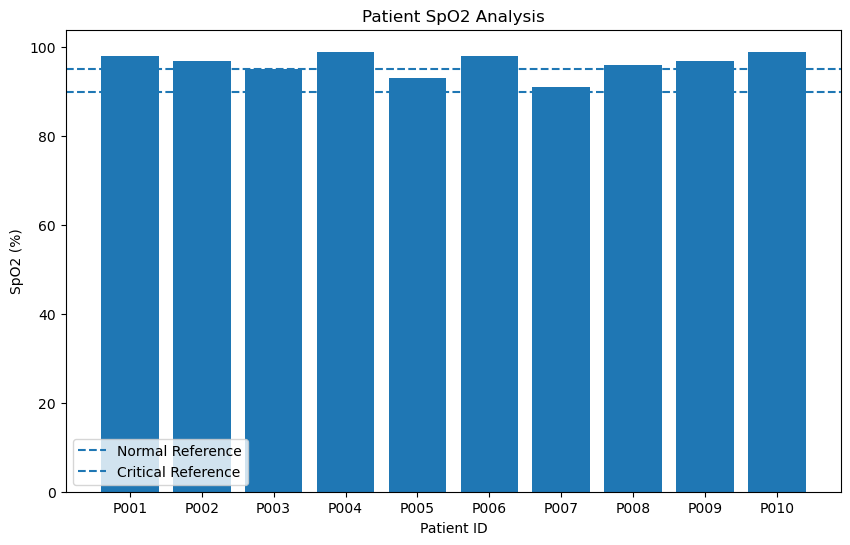

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(df["Patient_ID"], df["SpO2"])

plt.axhline(95, linestyle="--", label="Normal Reference")
plt.axhline(90, linestyle="--", label="Critical Reference")

plt.xlabel("Patient ID")
plt.ylabel("SpO2 (%)")
plt.title("Patient SpO2 Analysis")
plt.legend()

plt.show()

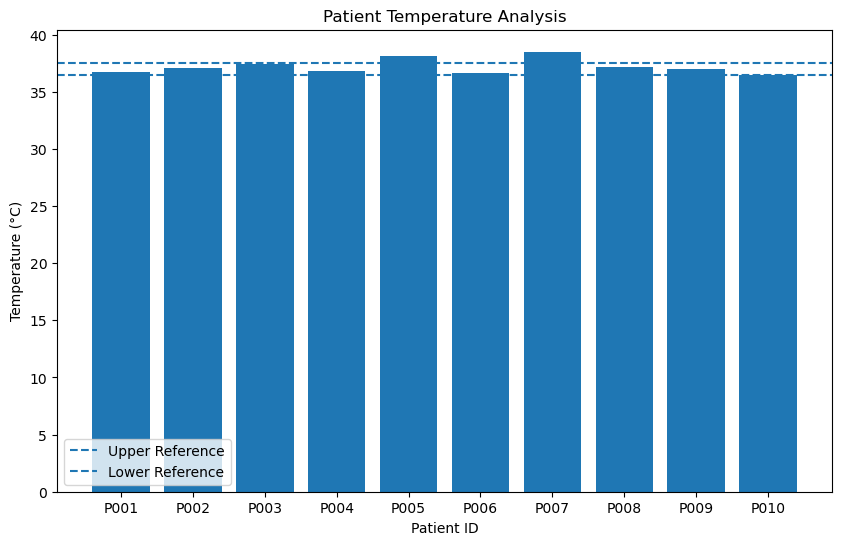

In [13]:
plt.figure(figsize=(10, 6))

plt.bar(df["Patient_ID"], df["Temperature"])

plt.axhline(37.5, linestyle="--", label="Upper Reference")
plt.axhline(36.5, linestyle="--", label="Lower Reference")

plt.xlabel("Patient ID")
plt.ylabel("Temperature (°C)")
plt.title("Patient Temperature Analysis")
plt.legend()

plt.show()

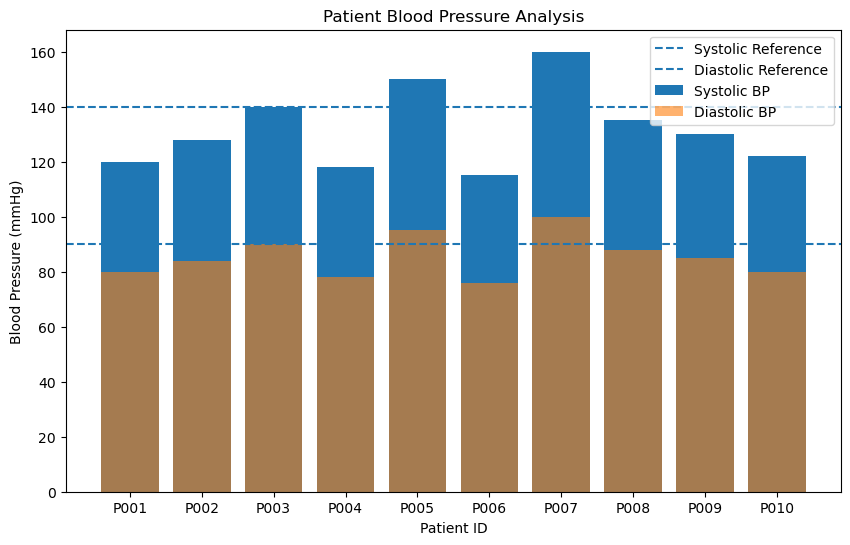

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(df["Patient_ID"], df["Systolic_BP"], label="Systolic BP")
plt.bar(df["Patient_ID"], df["Diastolic_BP"], 
        bottom=0, alpha=0.6, label="Diastolic BP")

plt.axhline(140, linestyle="--", label="Systolic Reference")
plt.axhline(90, linestyle="--", label="Diastolic Reference")

plt.xlabel("Patient ID")
plt.ylabel("Blood Pressure (mmHg)")
plt.title("Patient Blood Pressure Analysis")
plt.legend()

plt.show()

In [15]:
def assess_risk(row):
    risk_score = 0

    if row["Heart_Rate"] > 100:
        risk_score += 1

    if row["SpO2"] < 95:
        risk_score += 1

    if row["Temperature"] > 37.5:
        risk_score += 1

    if row["Systolic_BP"] > 140 or row["Diastolic_BP"] > 90:
        risk_score += 1

    if risk_score >= 2:
        return "Needs Attention"
    else:
        return "Normal"


df["Risk_Status"] = df.apply(assess_risk, axis=1)

df[[
    "Patient_ID",
    "Heart_Rate",
    "SpO2",
    "Temperature",
    "Systolic_BP",
    "Diastolic_BP",
    "Risk_Status"
]]

,Patient_ID,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP,Risk_Status
0,P001,72,98,36.7,120,80,Normal
1,P002,85,97,37.1,128,84,Normal
2,P003,91,95,37.4,140,90,Normal
3,P004,76,99,36.8,118,78,Normal
4,P005,102,93,38.1,150,95,Needs Attention
5,P006,68,98,36.6,115,76,Normal
6,P007,110,91,38.5,160,100,Needs Attention
7,P008,88,96,37.2,135,88,Normal
8,P009,79,97,37.0,130,85,Normal
9,P010,74,99,36.5,122,80,Normal


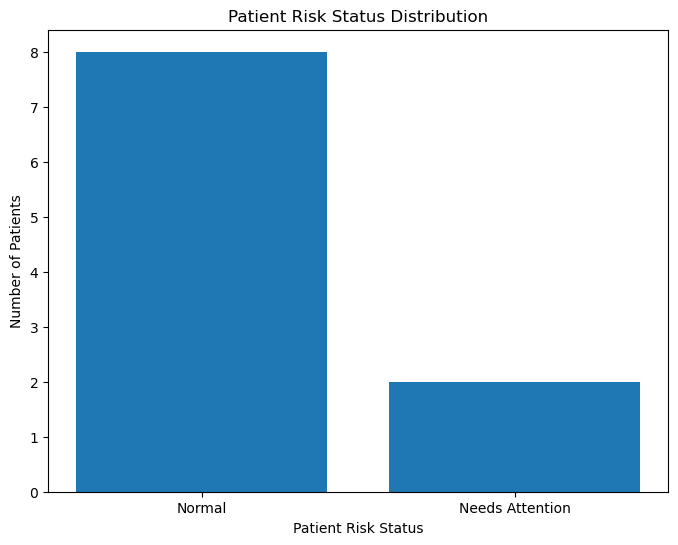

In [16]:
status_counts = df["Risk_Status"].value_counts()

plt.figure(figsize=(8, 6))

plt.bar(status_counts.index, status_counts.values)

plt.xlabel("Patient Risk Status")
plt.ylabel("Number of Patients")
plt.title("Patient Risk Status Distribution")

plt.show()

In [17]:
attention_patients = df[df["Risk_Status"] == "Needs Attention"]

attention_patients[
    ["Patient_ID", "Heart_Rate", "SpO2", "Temperature",
     "Systolic_BP", "Diastolic_BP", "Risk_Status"]
]

,Patient_ID,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP,Risk_Status
4,P005,102,93,38.1,150,95,Needs Attention
6,P007,110,91,38.5,160,100,Needs Attention


In [18]:
total_patients = len(df)
normal_patients = (df["Risk_Status"] == "Normal").sum()
attention_patients_count = (df["Risk_Status"] == "Needs Attention").sum()

avg_heart_rate = df["Heart_Rate"].mean()
avg_spo2 = df["SpO2"].mean()
avg_temperature = df["Temperature"].mean()
avg_systolic_bp = df["Systolic_BP"].mean()
avg_diastolic_bp = df["Diastolic_BP"].mean()

print("PATIENT VITAL SIGNS SUMMARY")
print("----------------------------")
print("Total Patients:", total_patients)
print("Normal Patients:", normal_patients)
print("Needs Attention:", attention_patients_count)
print("Average Heart Rate:", round(avg_heart_rate, 2), "bpm")
print("Average SpO2:", round(avg_spo2, 2), "%")
print("Average Temperature:", round(avg_temperature, 2), "°C")
print("Average Systolic BP:", round(avg_systolic_bp, 2), "mmHg")
print("Average Diastolic BP:", round(avg_diastolic_bp, 2), "mmHg")

PATIENT VITAL SIGNS SUMMARY
----------------------------
Total Patients: 10
Normal Patients: 8
Needs Attention: 2
Average Heart Rate: 84.5 bpm
Average SpO2: 96.3 %
Average Temperature: 37.19 °C
Average Systolic BP: 131.8 mmHg
Average Diastolic BP: 85.6 mmHg


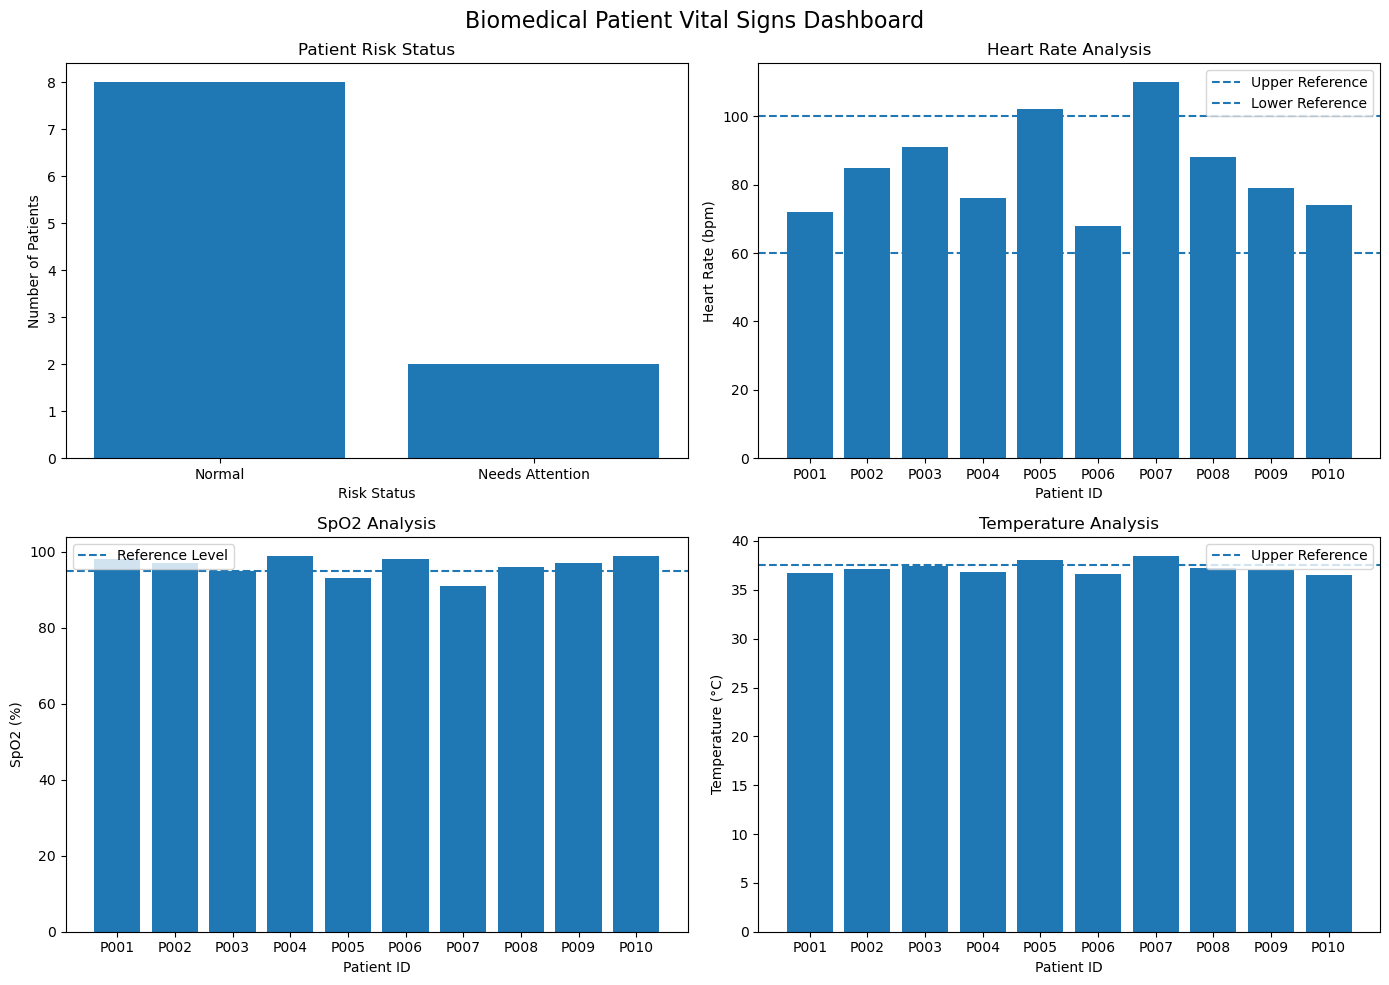

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Risk Status
risk_counts = df["Risk_Status"].value_counts()

axes[0, 0].bar(risk_counts.index, risk_counts.values)
axes[0, 0].set_title("Patient Risk Status")
axes[0, 0].set_xlabel("Risk Status")
axes[0, 0].set_ylabel("Number of Patients")

# 2. Heart Rate
axes[0, 1].bar(df["Patient_ID"], df["Heart_Rate"])
axes[0, 1].axhline(100, linestyle="--", label="Upper Reference")
axes[0, 1].axhline(60, linestyle="--", label="Lower Reference")
axes[0, 1].set_title("Heart Rate Analysis")
axes[0, 1].set_xlabel("Patient ID")
axes[0, 1].set_ylabel("Heart Rate (bpm)")
axes[0, 1].legend()

# 3. SpO2
axes[1, 0].bar(df["Patient_ID"], df["SpO2"])
axes[1, 0].axhline(95, linestyle="--", label="Reference Level")
axes[1, 0].set_title("SpO2 Analysis")
axes[1, 0].set_xlabel("Patient ID")
axes[1, 0].set_ylabel("SpO2 (%)")
axes[1, 0].legend()

# 4. Temperature
axes[1, 1].bar(df["Patient_ID"], df["Temperature"])
axes[1, 1].axhline(37.5, linestyle="--", label="Upper Reference")
axes[1, 1].set_title("Temperature Analysis")
axes[1, 1].set_xlabel("Patient ID")
axes[1, 1].set_ylabel("Temperature (°C)")
axes[1, 1].legend()

plt.suptitle("Biomedical Patient Vital Signs Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

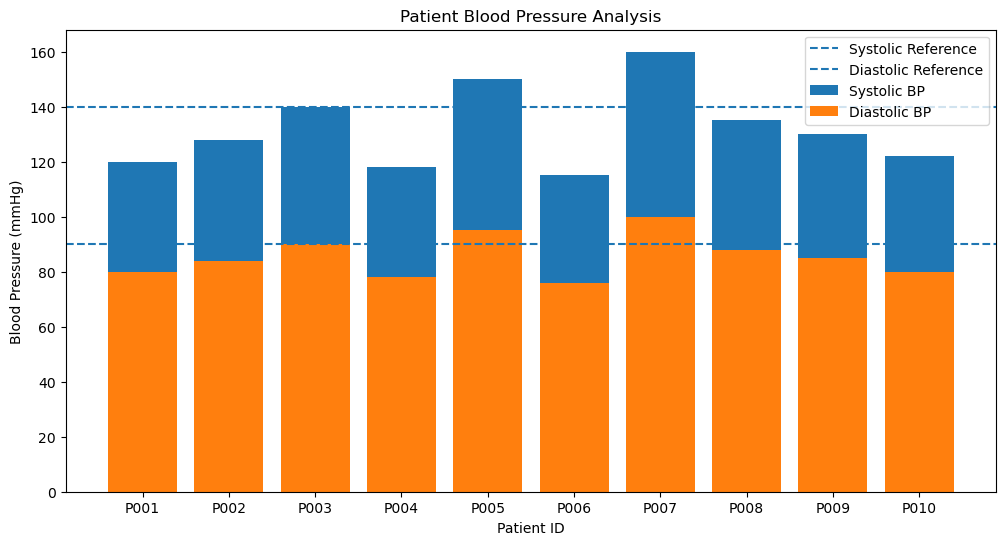

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    df["Patient_ID"],
    df["Systolic_BP"],
    label="Systolic BP"
)

plt.bar(
    df["Patient_ID"],
    df["Diastolic_BP"],
    label="Diastolic BP"
)

plt.axhline(140, linestyle="--", label="Systolic Reference")
plt.axhline(90, linestyle="--", label="Diastolic Reference")

plt.title("Patient Blood Pressure Analysis")
plt.xlabel("Patient ID")
plt.ylabel("Blood Pressure (mmHg)")
plt.legend()

plt.show()

In [21]:
correlation = df[
    ["Heart_Rate", "SpO2", "Temperature",
     "Systolic_BP", "Diastolic_BP"]
].corr()

correlation

,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP
Heart_Rate,1.000000,-0.956784,0.979906,0.982817,0.980362
SpO2,-0.956784,1.000000,-0.981219,-0.974688,-0.968706
Temperature,0.979906,-0.981219,1.000000,0.972149,0.965273
Systolic_BP,0.982817,-0.974688,0.972149,1.000000,0.997869
Diastolic_BP,0.980362,-0.968706,0.965273,0.997869,1.000000


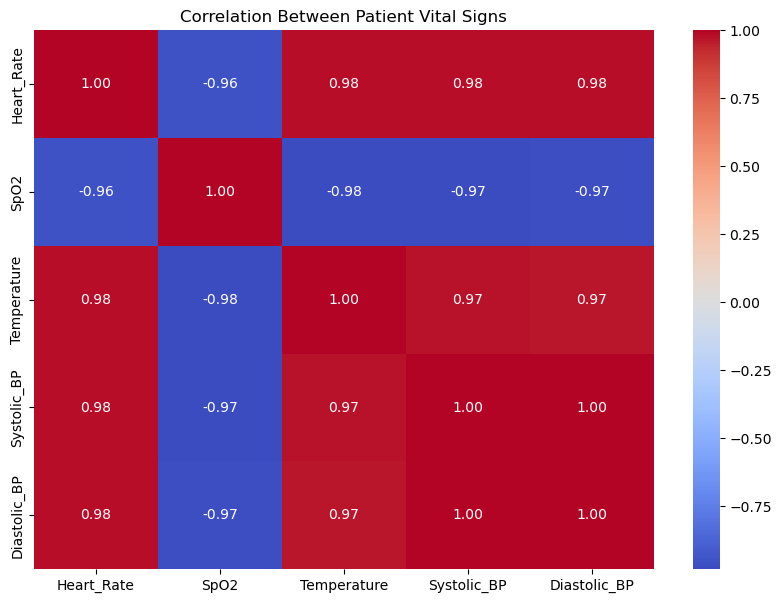

In [22]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Patient Vital Signs")
plt.show()

In [24]:
def identify_abnormal_vitals(row):
    abnormal = []

    if row["Heart_Rate"] > 100 or row["Heart_Rate"] < 60:
        abnormal.append("Heart Rate")

    if row["SpO2"] < 95:
        abnormal.append("SpO2")

    if row["Temperature"] > 37.5 or row["Temperature"] < 36.5:
        abnormal.append("Temperature")

    if row["Systolic_BP"] > 140 or row["Systolic_BP"] < 90:
        abnormal.append("Systolic BP")

    if row["Diastolic_BP"] > 90 or row["Diastolic_BP"] < 60:
        abnormal.append("Diastolic BP")

    if len(abnormal) == 0:
        return "None"

    return ", ".join(abnormal)


df["Abnormal_Vitals"] = df.apply(identify_abnormal_vitals, axis=1)

df[
    ["Patient_ID", "Risk_Status", "Abnormal_Vitals"]
]

,Patient_ID,Risk_Status,Abnormal_Vitals
0,P001,Normal,None
1,P002,Normal,None
2,P003,Normal,None
3,P004,Normal,None
4,P005,Needs Attention,"Heart Rate, SpO2, Temperature, Systolic BP, Di..."
5,P006,Normal,None
6,P007,Needs Attention,"Heart Rate, SpO2, Temperature, Systolic BP, Di..."
7,P008,Normal,None
8,P009,Normal,None
9,P010,Normal,None


In [25]:
risk_report = df[df["Risk_Status"] == "Needs Attention"][
    ["Patient_ID", "Heart_Rate", "SpO2", "Temperature",
     "Systolic_BP", "Diastolic_BP", "Abnormal_Vitals"]
]

risk_report

,Patient_ID,Heart_Rate,SpO2,Temperature,Systolic_BP,Diastolic_BP,Abnormal_Vitals
4,P005,102,93,38.1,150,95,"Heart Rate, SpO2, Temperature, Systolic BP, Di..."
6,P007,110,91,38.5,160,100,"Heart Rate, SpO2, Temperature, Systolic BP, Di..."


In [26]:
df.to_csv("patient_vitals_final_analysis.csv", index=False)

print("Final analysis saved successfully!")

Final analysis saved successfully!


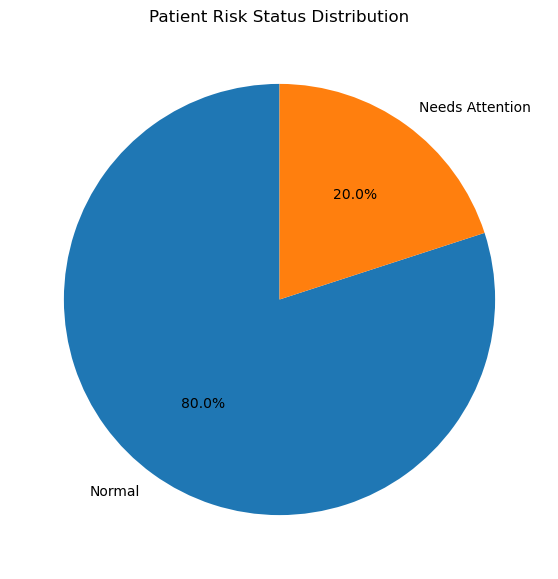

In [27]:
risk_counts = df["Risk_Status"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Patient Risk Status Distribution")
plt.show()

In [28]:
summary = pd.DataFrame({
    "Metric": [
        "Total Patients",
        "Normal Patients",
        "Needs Attention",
        "Average Heart Rate (bpm)",
        "Average SpO2 (%)",
        "Average Temperature (°C)",
        "Average Systolic BP (mmHg)",
        "Average Diastolic BP (mmHg)"
    ],
    "Value": [
        total_patients,
        normal_patients,
        attention_patients_count,
        round(avg_heart_rate, 2),
        round(avg_spo2, 2),
        round(avg_temperature, 2),
        round(avg_systolic_bp, 2),
        round(avg_diastolic_bp, 2)
    ]
})

summary

,Metric,Value
0,Total Patients,10.00
1,Normal Patients,8.00
2,Needs Attention,2.00
3,Average Heart Rate (bpm),84.50
4,Average SpO2 (%),96.30
5,Average Temperature (°C),37.19
6,Average Systolic BP (mmHg),131.80
7,Average Diastolic BP (mmHg),85.60


In [29]:
summary.to_csv("patient_vitals_summary.csv", index=False)

print("Summary report saved successfully!")

Summary report saved successfully!


In [30]:
print("======================================")
print("   PATIENT VITAL SIGNS ANALYSIS")
print("======================================")

print(f"Total patients analyzed: {total_patients}")
print(f"Normal patients: {normal_patients}")
print(f"Patients needing attention: {attention_patients_count}")

print("\nAverage Vital Signs:")
print(f"Heart Rate: {avg_heart_rate:.2f} bpm")
print(f"SpO2: {avg_spo2:.2f} %")
print(f"Temperature: {avg_temperature:.2f} °C")
print(f"Systolic BP: {avg_systolic_bp:.2f} mmHg")
print(f"Diastolic BP: {avg_diastolic_bp:.2f} mmHg")

print("\nPatients Requiring Attention:")
for patient in attention_patients["Patient_ID"]:
    print("-", patient)

print("\nAnalysis completed successfully!")

   PATIENT VITAL SIGNS ANALYSIS
Total patients analyzed: 10
Normal patients: 8
Patients needing attention: 2

Average Vital Signs:
Heart Rate: 84.50 bpm
SpO2: 96.30 %
Temperature: 37.19 °C
Systolic BP: 131.80 mmHg
Diastolic BP: 85.60 mmHg

Patients Requiring Attention:
- P005
- P007

Analysis completed successfully!
